In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/faizanhaider01/study-grdes/Study_grade Data.csv


In [6]:
df = pd.read_csv('/kaggle/input/datasets/faizanhaider01/study-grdes/Study_grade Data.csv')

In [7]:
df.sample(5)

,study_hours,exam_score
182,1.2,53.0
207,2.4,63.2
208,0.9,50.9
5,2.2,59.6
146,4.5,79.8


In [10]:
df['exam_score']=df['exam_score']/10

In [12]:
df.sample(4)

,study_hours,exam_score
91,2.1,5.94
85,1.3,5.31
33,1.6,5.56
204,6.8,9.79


In [14]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'exam_score')

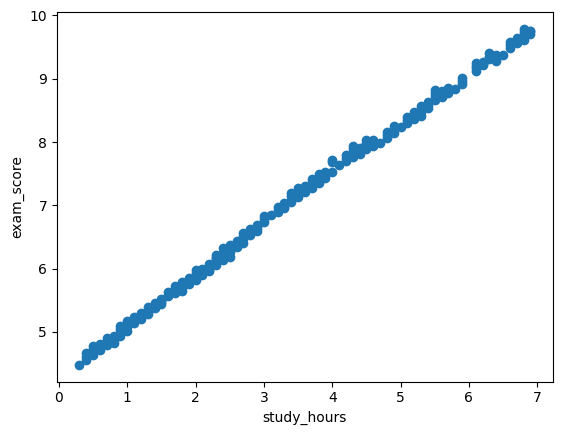

In [15]:
plt.scatter(df['study_hours'],df['exam_score'])
plt.xlabel('study_hours')
plt.ylabel('exam_score')


In [16]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [17]:
y

0      5.23
1      6.18
2      4.87
3      6.84
4      7.52
       ... 
206    8.03
207    6.32
208    5.09
209    8.83
210    7.50
Name: exam_score, Length: 211, dtype: float64

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lr = LinearRegression()

In [21]:
lr.fit(X_train,y_train)

LinearRegression()

Text(0, 0.5, 'exam_score')

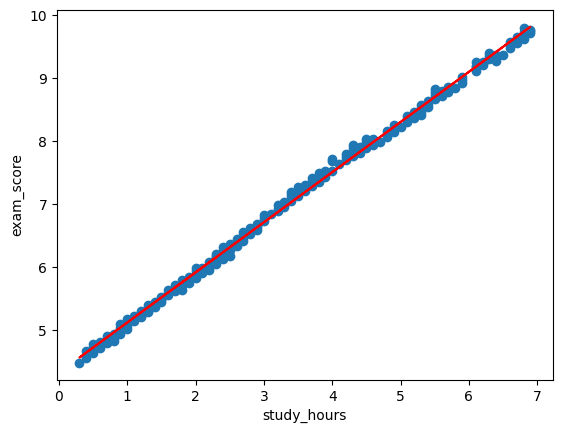

In [22]:
plt.scatter(df['study_hours'],df['exam_score'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('study_hours')
plt.ylabel('exam_score')


In [23]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [27]:
y_pred = lr.predict(X_test)

In [25]:
y_test.values

array([8.2 , 7.89, 4.63, 4.82, 7.03, 7.68, 5.85, 7.8 , 7.14, 5.01, 5.28,
       5.25, 7.37, 5.99, 9.31, 6.41, 7.86, 8.07, 8.36, 9.37, 9.62, 8.15,
       5.52, 5.8 , 5.79, 9.74, 8.3 , 6.27, 8.73, 8.41, 4.94, 6.67, 8.67,
       5.64, 4.79, 5.96, 5.67, 4.87, 5.47, 6.84, 6.62, 8.84, 4.73])

In [28]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.06961582397575321


In [29]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.0068060961698514265


In [30]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.08249906769080137


In [34]:
print("r2",r2_score(y_test,y_pred))

r2 0.997096174889635


In [ ]:
r2 = r2_score(y_test,y_pred)

In [32]:
#adjusted R2 score
r2 = r2_score(y_test,y_pred)
X_test.shape

(43, 1)

In [33]:
1 - ((1-r2)*(43-1)/(43-1-1))

0.9970253498869431

In [36]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(211)

new_df1 = new_df1[['study_hours','random_feature','exam_score']]
new_df1.head()

,study_hours,random_feature,exam_score
0,1.2,0.702760,5.23
1,2.5,0.090632,6.18
2,0.8,0.597890,4.87
3,3.1,0.955942,6.84
4,4.0,0.074949,7.52


Text(0, 0.5, 'exam_score')

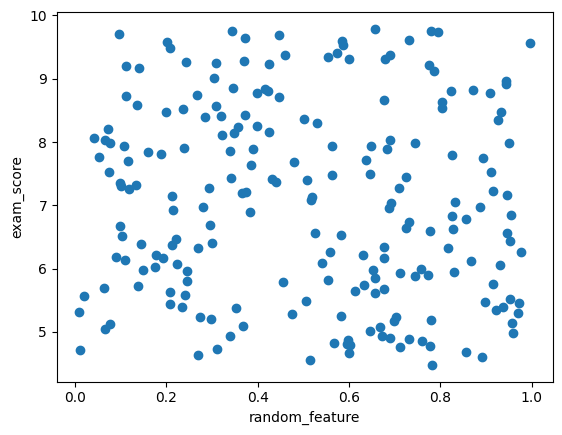

In [37]:
plt.scatter(new_df1['random_feature'],new_df1['exam_score'])
plt.xlabel('random_feature')
plt.ylabel('exam_score')

In [38]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [40]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [41]:
y_pred = lr.predict(X_test)

In [42]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.997048811594025


In [43]:
1 - ((1-r2)*(43-1)/(43-1-2))  

0.9969012521737263

# NOTE:
you will observe that it is not affected because model is too much linear 
which touches the points almost all which is ideal or not possible 
case when you work with real world datas But when you observe changes 
in r2 score and adjusted r2 then it means that your irrelevant ot 
relevant addition of input cols effected your y 